<a href="https://colab.research.google.com/github/abeeraz379/auto_mpg_dirty_MachineLearningProject/blob/main/auto_mpg_dirty.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Search for the best prediction model for regression problems
- By: ABeer Al-Zebda|Machine Learning Engineer

# Import libraries

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error,root_mean_squared_error
from sklearn.ensemble import BaggingRegressor as Bagging
from sklearn.ensemble import RandomForestRegressor as RandomForest
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import GradientBoostingClassifier
from sklearn import set_config
set_config(transform_output='pandas')

# load and Inspect the Data

In [2]:
df=pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/02-IntroML/Week06/Data/auto_mpg_dirty.csv')
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130.0,3504.0,12.0,70,America,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,America,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,America,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,America,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,America,ford torino


# Explore the Data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        355 non-null    float64
 5   acceleration  375 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        333 non-null    object 
 8   car name      398 non-null    object 
dtypes: float64(5), int64(2), object(2)
memory usage: 28.1+ KB


# Feature Details

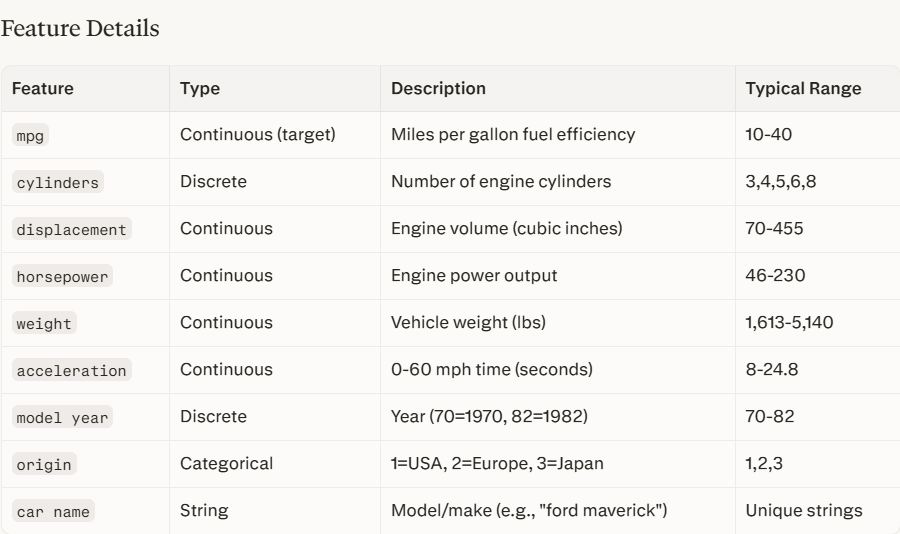

In [4]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year
count,398.000000,398.000000,398.000000,392.000000,355.000000,375.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.887324,15.538400,76.010050
std,7.815984,1.701004,104.269838,38.491160,834.403944,2.784145,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2229.000000,13.750000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2807.000000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3607.000000,17.150000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


 all these features are in normal range , so there is **no outliers**

In [5]:
df.describe(include='object')

,origin,car name
count,333,398
unique,3,305
top,America,ford pinto
freq,215,6


In [6]:
df.isna().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,43
acceleration,23
model year,0
origin,65
car name,0


In [7]:
df.duplicated().sum()

np.int64(0)

# Evaluation Function

In [8]:
# Add custom functions (from snippets if you have saved it)

def regression_metrics(y_true, y_pred, label='', verbose = True, output_dict=False):
  # Get metrics
  mae = mean_absolute_error(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)
  rmse= root_mean_squared_error(y_true, y_pred)
  r_squared = r2_score(y_true, y_pred)
  if verbose == True:
    # Print Result with Label and Header
    header = "-"*60
    print(header, f"Regression Metrics: {label}", header, sep='\n')
    print(f"- MAE = {mae:,.3f}")
    print(f"- MSE = {mse:,.3f}")
    print(f"- RMSE = {rmse:,.3f}")
    print(f"- R^2 = {r_squared:,.3f}")
  if output_dict == True:
      metrics = {'Label':label, 'MAE':mae,
                 'MSE':mse, 'RMSE':rmse, 'R^2':r_squared}
      return metrics

def evaluate_regression(reg, X_train, y_train, X_test, y_test, verbose = True,
                        output_frame=False):
  # Get predictions for training data
  y_train_pred = reg.predict(X_train)

  # Call the helper function to obtain regression metrics for training data
  results_train = regression_metrics(y_train, y_train_pred, verbose = verbose,
                                     output_dict=output_frame,
                                     label='Training Data')
  print()
  # Get predictions for test data
  y_test_pred = reg.predict(X_test)
  # Call the helper function to obtain regression metrics for test data
  results_test = regression_metrics(y_test, y_test_pred, verbose = verbose,
                                  output_dict=output_frame,
                                    label='Test Data' )

  # Store results in a dataframe if ouput_frame is True
  if output_frame:
    results_df = pd.DataFrame([results_train,results_test])
    # Set the label as the index
    results_df = results_df.set_index('Label')
    # Set index.name to none to get a cleaner looking result
    results_df.index.name=None
    # Return the dataframe
    return results_df.round(3)

# Data Preprocessing

## define X and y

In [9]:
# drop car name column and define x and y
y = df['mpg']
x =df.drop(columns=['mpg','car name'], axis=1)

## split the data into training and testing

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42)

## create pipeline for numeric and categorical

In [11]:
# Create the preprocessing pipeline for numeric data
# (New) Select columns wiht make_column)selector
num_selector = make_column_selector(dtype_include='number')
# Instantiate the transformers
scaler = StandardScaler()
mean_imputer = SimpleImputer(strategy='mean')
# Instantiate the pipeline
num_pipe = make_pipeline(mean_imputer, scaler)
# Make the tuple for ColumnTransformer
num_tuple = ('numeric',num_pipe, num_selector)
num_tuple

('numeric',
 Pipeline(steps=[('simpleimputer', SimpleImputer()),
                 ('standardscaler', StandardScaler())]),
 <sklearn.compose._column_transformer.make_column_selector at 0x7840b9934260>)

In [12]:
# define the object columns from the x_train
cat_cols=x_train.select_dtypes('object').columns
cat_cols

Index(['origin'], dtype='object')

In [13]:
# Create the preprocessing pipeline for categorical data
# (New) Select columns with make_column_selector
cat_selector = make_column_selector(dtype_include='object')
# Insantiate transfomers
freq_imputer = SimpleImputer(strategy='most_frequent')
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
# Instantiate the pipeline
cat_pipe = make_pipeline(freq_imputer, ohe)
# Make a tuple for column transformer
cat_tuple = ('categorical',cat_pipe, cat_selector)
cat_tuple

('categorical',
 Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='most_frequent')),
                 ('onehotencoder',
                  OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
 <sklearn.compose._column_transformer.make_column_selector at 0x7840b98e71d0>)

## create column Tranformer

In [14]:
# Create the preprocessing ColumnTransformer
preprocessor = ColumnTransformer([cat_tuple, num_tuple],
verbose_feature_names_out=False)

preprocessor

ColumnTransformer(transformers=[('categorical',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x7840b98e71d0>),
                                ('numeric',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer()),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x7840b9934260>)],
                  verbose_feature_names_out=False)

# Models

## linear regression model

In [15]:
# Instantiate a linear regression model
linreg = LinearRegression()


In [16]:
# Combine the preprocessing ColumnTransformer and the linear regression model in a Pipeline
linreg_pipe = make_pipeline(preprocessor, linreg)
linreg_pipe

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('categorical',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7840b98e71d0>),
                                                 ('numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7840b9934260>)],
                                   verbose_feature_names_out=False)),
                ('linearregression', LinearRegression())])

In [17]:
linreg_pipe.fit(x_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('categorical',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7840b98e71d0>),
                                                 ('numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7840b9934260>)],
                                   verbose_feature_names_out=False)),
                ('linearregression', LinearRegression())])

In [18]:
linear_reg_evaluate=evaluate_regression(linreg_pipe, x_train, y_train, x_test, y_test)
linear_reg_evaluate

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 2.719
- MSE = 13.118
- RMSE = 3.622
- R^2 = 0.790

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 2.773
- MSE = 12.459
- RMSE = 3.530
- R^2 = 0.781


## Random Forest Model

In [19]:
# Instantiate a RandomForest model
rf = RandomForest()


In [20]:
# Combine the preprocessing ColumnTransformer and the RandomForest model in a Pipeline
RandomForest_pipe = make_pipeline(preprocessor, rf)
RandomForest_pipe

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('categorical',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7840b98e71d0>),
                                                 ('numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7840b9934260>)],
                                   verbose_feature_names_out=False)),
                ('randomforestregressor', RandomForestRegressor())])

In [21]:
RandomForest_pipe.fit(x_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('categorical',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7840b98e71d0>),
                                                 ('numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7840b9934260>)],
                                   verbose_feature_names_out=False)),
                ('randomforestregressor', RandomForestRegressor())])

In [22]:
RandomForest_evaluate=evaluate_regression(RandomForest_pipe, x_train, y_train, x_test, y_test)
RandomForest_evaluate

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 0.767
- MSE = 1.272
- RMSE = 1.128
- R^2 = 0.980

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 1.920
- MSE = 7.529
- RMSE = 2.744
- R^2 = 0.867


## Tuning RandomForest model with GridSearchCv

In [23]:
# Always helpful to see available paramters
RandomForest_pipe.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('categorical',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(strategy='most_frequent')),
                                                    ('onehotencoder',
                                                     OneHotEncoder(handle_unknown='ignore',
                                                                   sparse_output=False))]),
                                    <sklearn.compose._column_transformer.make_column_selector object at 0x7840b98e71d0>),
                                   ('numeric',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer()),
                                                    ('standardscaler',
                                                     StandardScaler())]),
                         

In [24]:
# Define param grid with options to try
param_grid = {
    'randomforestregressor__n_estimators': [50, 100, 200],
    'randomforestregressor__max_depth': [None, 10, 20],
    'randomforestregressor__min_samples_split': [2, 5],
    'randomforestregressor__max_features': ['sqrt', 0.5]
}


In [25]:
# Instantiate the gridsearch (fix n_jobs=-1)
gridsearch = GridSearchCV(RandomForest_pipe, param_grid, n_jobs=-1, verbose=1,cv=5)

# Fit the gridsearch on the training data
gridsearch.fit(x_train, y_train)

# Obtain the best parameters from the gridsearch
print(gridsearch.best_params_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
{'randomforestregressor__max_depth': None, 'randomforestregressor__max_features': 0.5, 'randomforestregressor__min_samples_split': 2, 'randomforestregressor__n_estimators': 200}


In [26]:
# Define a model with the best parameters already refit on the entire trainingset

best_rf = gridsearch.best_estimator_
# Evalute the tuned model
best_rf_evaluate=evaluate_regression(best_rf, x_train, y_train, x_test, y_test)
best_rf_evaluate

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 0.753
- MSE = 1.239
- RMSE = 1.113
- R^2 = 0.980

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 1.826
- MSE = 6.366
- RMSE = 2.523
- R^2 = 0.888


## Bagging model

In [27]:
# Instantiate a Bagging model
Bagging = Bagging()


In [28]:
# Combine the preprocessing ColumnTransformer and the Bagging model in a Pipeline
Bagging_pipe = make_pipeline(preprocessor, Bagging)
Bagging_pipe

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('categorical',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7840b98e71d0>),
                                                 ('numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7840b9934260>)],
                                   verbose_feature_names_out=False)),
                ('baggingregressor', BaggingRegressor())])

In [29]:
Bagging_pipe.fit(x_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('categorical',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7840b98e71d0>),
                                                 ('numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7840b9934260>)],
                                   verbose_feature_names_out=False)),
                ('baggingregressor', BaggingRegressor())])

In [30]:
Bagging_evaluate=evaluate_regression(Bagging_pipe, x_train, y_train, x_test, y_test)
Bagging_evaluate

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 0.877
- MSE = 1.731
- RMSE = 1.316
- R^2 = 0.972

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 1.868
- MSE = 6.973
- RMSE = 2.641
- R^2 = 0.877


## Tuning RandomForest model with GridSearchCv

In [31]:
# Always helpful to see available paramters
Bagging_pipe.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('categorical',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(strategy='most_frequent')),
                                                    ('onehotencoder',
                                                     OneHotEncoder(handle_unknown='ignore',
                                                                   sparse_output=False))]),
                                    <sklearn.compose._column_transformer.make_column_selector object at 0x7840b98e71d0>),
                                   ('numeric',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer()),
                                                    ('standardscaler',
                                                     StandardScaler())]),
                         

In [32]:
# Define parameters to tune
param_grid = {
    'baggingregressor__n_estimators': [5, 10, 20, 30, 40, 50],
    'baggingregressor__max_samples': [0.5, 0.7, 0.9],
    'baggingregressor__max_features': [0.5, 0.7, 0.9]
}

In [33]:
# Instantiate the gridsearch (fix n_jobs=-1)
gridsearch2 = GridSearchCV(Bagging_pipe, param_grid, n_jobs=-1, verbose=1,cv=5)

# Fit the gridsearch on the training data
gridsearch2.fit(x_train, y_train)

# Obtain the best parameters from the gridsearch
print(gridsearch2.best_params_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
{'baggingregressor__max_features': 0.9, 'baggingregressor__max_samples': 0.7, 'baggingregressor__n_estimators': 50}


In [34]:
# Define a model with the best parameters already refit on the entire trainingset

best_Bagging = gridsearch2.best_estimator_
# Evalute the tuned model
best_Bagging_evaluate= evaluate_regression(best_Bagging, x_train, y_train, x_test, y_test)
best_Bagging_evaluate

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 1.042
- MSE = 2.323
- RMSE = 1.524
- R^2 = 0.963

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 1.875
- MSE = 6.716
- RMSE = 2.592
- R^2 = 0.882


## Support Vector Regression

In [51]:
svr=SVR(kernel='rbf')

In [53]:
svm_pipe = make_pipeline(
    preprocessor,
    svr)



In [54]:
svm_pipe.fit(x_train,y_train)


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('categorical',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7840b98e71d0>),
                                                 ('numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7840b9934260>)],
                                   verbose_feature_names_out=False)),
                ('svr', SVR())])

In [55]:
svm_evaluate=evaluate_regression(svm_pipe, x_train, y_train, x_test, y_test)
svm_evaluate

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 2.165
- MSE = 10.727
- RMSE = 3.275
- R^2 = 0.828

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 2.109
- MSE = 8.837
- RMSE = 2.973
- R^2 = 0.844


## Gradient Boosting Regressor

In [57]:

gbr = GradientBoostingRegressor(random_state=42)

gbr_pipe = make_pipeline(
    preprocessor,
    gbr
)

gbr_pipe.fit(x_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('categorical',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7840b98e71d0>),
                                                 ('numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7840b9934260>)],
                                   verbose_feature_names_out=False)),
                ('gradientboostingregressor',
                 GradientBoostingRegressor(random_state=42))])

In [58]:
gbr_evaluate=evaluate_regression(gbr_pipe, x_train, y_train, x_test, y_test)
gbr_evaluate

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 1.042
- MSE = 1.758
- RMSE = 1.326
- R^2 = 0.972

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 1.933
- MSE = 7.739
- RMSE = 2.782
- R^2 = 0.864


# Comparing

In [60]:

linear_reg_evaluate = evaluate_regression(linreg_pipe, x_train, y_train, x_test, y_test, verbose=False, output_frame=True)
RandomForest_evaluate = evaluate_regression(RandomForest_pipe, x_train, y_train, x_test, y_test, verbose=False, output_frame=True)
Bagging_evaluate = evaluate_regression(Bagging_pipe, x_train, y_train, x_test, y_test, verbose=False, output_frame=True)
best_rf_evaluate = evaluate_regression(best_rf, x_train, y_train, x_test, y_test, verbose=False, output_frame=True)
best_Bagging_evaluate = evaluate_regression(best_Bagging, x_train, y_train, x_test, y_test, verbose=False, output_frame=True)
svm_evaluate=evaluate_regression(svm_pipe, x_train, y_train, x_test, y_test, verbose=False, output_frame=True)
gbr_evaluate=evaluate_regression(gbr_pipe, x_train, y_train, x_test, y_test, verbose=False, output_frame=True)
model_results = {
    'linear': linear_reg_evaluate,
    'RandomForestrf': RandomForest_evaluate,
    'best_RandomForest': best_rf_evaluate,
    'Bagging': Bagging_evaluate,
    'best_Bagging': best_Bagging_evaluate,
    'Support Vector Regression': svm_evaluate,
    'Gradient Boosting Regressor': gbr_evaluate
}



frames = []
for model_name, result_df in model_results.items():
    for split in result_df.columns:  # e.g., 'Train', 'Test'
        row = result_df[split].to_dict()
        row['Model'] = model_name
        row['Split'] = split
        frames.append(row)

comparison_df = pd.DataFrame(frames).set_index(['Model', 'Split']).round(3)

print("MODEL COMPARISON - Train/Test Metrics")
print("=" * 80)
comparison_df








MODEL COMPARISON - Train/Test Metrics


Training Data  Test Data
Model                       Split                          
linear                      MAE            2.719      2.773
                            MSE           13.118     12.459
                            RMSE           3.622      3.530
                            R^2            0.790      0.781
RandomForestrf              MAE            0.767      1.920
                            MSE            1.272      7.529
                            RMSE           1.128      2.744
                            R^2            0.980      0.867
best_RandomForest           MAE            0.753      1.826
                            MSE            1.239      6.366
                            RMSE           1.113      2.523
                            R^2            0.980      0.888
Bagging                     MAE            0.877      1.868
                            MSE            1.731      6.973
                            RMSE           1.316      2.641
                            R^2            0.972      0.877
best_Bagging                MAE            1.042      1.875
                            MSE            2.323      6.716
                            RMSE           1.524      2.592
                            R^2            0.963      0.882
Support Vector Regression   MAE            2.165      2.109
                            MSE           10.727      8.837
                            RMSE           3.275      2.973
                            R^2            0.828      0.844
Gradient Boosting Regressor MAE            1.042      1.933
                            MSE            1.758      7.739
                            RMSE           1.326      2.782
                            R^2            0.972      0.864

In [63]:
print(comparison_df.columns.tolist())
print(comparison_df.head())

['Training Data', 'Test Data']
                      Training Data  Test Data
Model          Split                          
linear         MAE            2.719      2.773
               MSE           13.118     12.459
               RMSE           3.622      3.530
               R^2            0.790      0.781
RandomForestrf MAE            0.767      1.920


In [64]:
import pandas as pd

# Rename columns to simpler names
comparison_df.columns = ['Train', 'Test']

# Reset index so Model and Split (metric) become columns
df = comparison_df.reset_index()
df.columns = ['Model', 'Metric', 'Train', 'Test']

# Pivot: one row per Model, one column per metric+split combo
wide = df.pivot(index='Model', columns='Metric', values=['Train', 'Test'])

# Flatten MultiIndex columns: ('Train', 'MAE') -> 'MAE_Train'
wide.columns = [f"{metric}_{split}" for split, metric in wide.columns]

# Rename R^2 columns to R2 (no caret)
wide = wide.rename(columns=lambda c: c.replace('R^2', 'R2'))

# Compute train/test gaps (overfitting indicators)
wide['MAE_gap']  = (wide['MAE_Train']  - wide['MAE_Test']).abs()
wide['MSE_gap']  = (wide['MSE_Train']  - wide['MSE_Test']).abs()
wide['RMSE_gap'] = (wide['RMSE_Train'] - wide['RMSE_Test']).abs()
wide['R2_gap']   = (wide['R2_Train']   - wide['R2_Test']).abs()

# Composite ranking score (lower = better)
wide['score'] = (
    wide['MAE_Test'].rank(method='min')     +
    wide['MSE_Test'].rank(method='min')     +
    wide['RMSE_Test'].rank(method='min')    +
    (-wide['R2_Test']).rank(method='min')   +
    wide['MAE_gap'].rank(method='min')      +
    wide['MSE_gap'].rank(method='min')      +
    wide['RMSE_gap'].rank(method='min')     +
    wide['R2_gap'].rank(method='min')
)

# Sort by score ascending (rank 1 = best model)
best_models = wide.sort_values('score')

# Display
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

display_cols = [
    'MAE_Test', 'MSE_Test', 'RMSE_Test', 'R2_Test',
    'MAE_gap',  'MSE_gap',  'RMSE_gap',  'R2_gap',
    'score'
]

print("=" * 80)
print("Model Ranking: Test Performance + Generalization (lower score = better)")
print("=" * 80)
print(best_models[display_cols])

print("\n Best Model:", best_models.index[0])
print(f"   Score      : {best_models['score'].iloc[0]:.0f}")
print(f"   MAE  (Test): {best_models['MAE_Test'].iloc[0]:.4f}")
print(f"   RMSE (Test): {best_models['RMSE_Test'].iloc[0]:.4f}")
print(f"   R2   (Test): {best_models['R2_Test'].iloc[0]:.4f}")

Model Ranking: Test Performance + Generalization (lower score = better)
                             MAE_Test  MSE_Test  RMSE_Test  R2_Test  MAE_gap  \
Model                                                                          
best_Bagging                   1.8750    6.7160     2.5920   0.8820   0.8330   
best_RandomForest              1.8260    6.3660     2.5230   0.8880   1.0730   
Bagging                        1.8680    6.9730     2.6410   0.8770   0.9910   
Support Vector Regression      2.1090    8.8370     2.9730   0.8440   0.0560   
linear                         2.7730   12.4590     3.5300   0.7810   0.0540   
Gradient Boosting Regressor    1.9330    7.7390     2.7820   0.8640   0.8910   
RandomForestrf                 1.9200    7.5290     2.7440   0.8670   1.1530   

                             MSE_gap  RMSE_gap  R2_gap   score  
Model                                                           
best_Bagging                  4.3930    1.0680  0.0810 21.0000  
best_RandomF

In [65]:
display_cols = [
    # Test metrics
    'MAE_Train',  'MAE_Test',
    'MSE_Train',  'MSE_Test',
    'RMSE_Train', 'RMSE_Test',
    'R2_Train',   'R2_Test',
    # Gaps
    'MAE_gap', 'MSE_gap', 'RMSE_gap', 'R2_gap',
    'score'
]

print("=" * 120)
print("Model Ranking: Test Performance + Generalization (lower score = better)")
print("=" * 120)
print(best_models[display_cols].to_string())

print("\n Best Model:", best_models.index[0])
print(f"   Score      : {best_models['score'].iloc[0]:.0f}")
print(f"   MAE  (Train): {best_models['MAE_Train'].iloc[0]:.4f}  |  MAE  (Test): {best_models['MAE_Test'].iloc[0]:.4f}")
print(f"   RMSE (Train): {best_models['RMSE_Train'].iloc[0]:.4f}  |  RMSE (Test): {best_models['RMSE_Test'].iloc[0]:.4f}")
print(f"   R2   (Train): {best_models['R2_Train'].iloc[0]:.4f}  |  R2   (Test): {best_models['R2_Test'].iloc[0]:.4f}")

Model Ranking: Test Performance + Generalization (lower score = better)
                             MAE_Train  MAE_Test  MSE_Train  MSE_Test  RMSE_Train  RMSE_Test  R2_Train  R2_Test  MAE_gap  MSE_gap  RMSE_gap  R2_gap   score
Model                                                                                                                                                      
best_Bagging                    1.0420    1.8750     2.3230    6.7160      1.5240     2.5920    0.9630   0.8820   0.8330   4.3930    1.0680  0.0810 21.0000
best_RandomForest               0.7530    1.8260     1.2390    6.3660      1.1130     2.5230    0.9800   0.8880   1.0730   5.1270    1.4100  0.0920 23.0000
Bagging                         0.8770    1.8680     1.7310    6.9730      1.3160     2.6410    0.9720   0.8770   0.9910   5.2420    1.3250  0.0950 30.0000
Support Vector Regression       2.1650    2.1090    10.7270    8.8370      3.2750     2.9730    0.8280   0.8440   0.0560   1.8900    0.3020  0.0160 

**Based on these results we can say that the best model for this data is Tuned Bagging , caues it shows the less MSE, MAE , RMSE, and the higher R2 and the less diference for results between Training and Testing**

**But that was not enough to finalize the answer , I will search more for other way to make sure to find the best answer**

In [72]:
# 1. Flag overfitting explicitly
wide['overfit'] = (
    (wide['R2_Train'] - wide['R2_Test'] > 0.05) |   # R2 drops more than 5%
    (wide['RMSE_gap'] > wide['RMSE_Test'] * 0.15)    # RMSE gap > 15% of test RMSE
)

# 2. Normalize metrics for fair visual comparison
from sklearn.preprocessing import MinMaxScaler

scale_cols = ['MAE_Test', 'MSE_Test', 'RMSE_Test', 'R2_gap', 'MAE_gap', 'RMSE_gap']
scaler = MinMaxScaler()
wide_normalized = wide[scale_cols].copy()
wide_normalized[scale_cols] = scaler.fit_transform(wide[scale_cols])
# Invert R2_Test so lower = better (consistent direction)
wide_normalized['R2_Test_inv'] = 1 - scaler.fit_transform(wide[['R2_Test']])

# 3. Weighted score (optional: prioritize generalization over raw error)
wide['weighted_score'] = (
    1.5 * wide['MAE_Test'].rank(method='min')    +   # weight accuracy more
    1.0 * wide['RMSE_Test'].rank(method='min')   +
    1.5 * (-wide['R2_Test']).rank(method='min')  +
    2.0 * wide['R2_gap'].rank(method='min')      +   # heavily penalize overfitting
    2.0 * wide['RMSE_gap'].rank(method='min')
)

print(wide[['R2_Train', 'R2_Test', 'RMSE_Test', 'R2_gap', 'overfit', 'score', 'weighted_score']]
      .sort_values('weighted_score'))

                             R2_Train  R2_Test  RMSE_Test  R2_gap  overfit  \
Model                                                                        
best_Bagging                   0.9630   0.8820     2.5920  0.0810     True   
best_RandomForest              0.9800   0.8880     2.5230  0.0920     True   
Bagging                        0.9720   0.8770     2.6410  0.0950     True   
Support Vector Regression      0.8280   0.8440     2.9730  0.0160    False   
linear                         0.7900   0.7810     3.5300  0.0090    False   
Gradient Boosting Regressor    0.9720   0.8640     2.7820  0.1080     True   
RandomForestrf                 0.9800   0.8670     2.7440  0.1130     True   

                              score  weighted_score  
Model                                                
best_Bagging                21.0000         21.5000  
best_RandomForest           23.0000         22.0000  
Bagging                     30.0000         28.5000  
Support Vector Regression  

**These result get me confused , Is it more important to not be overfit or to be less weighted score , and the overfit calculation based on what ? **